In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [185]:
# reading both survey files
arise = pd.read_csv("arise_dataset.csv")
civic = pd.read_csv("CivicPulse_KS.csv")

print("ARISE shape:", arise.shape)
print("CivicPulse shape:", civic.shape)

ARISE shape: (309, 91)
CivicPulse shape: (135, 74)


In [186]:
#checking the first few rows
display(arise.head())
display(civic.head())


,Unnamed: 0,ResponseId,RecipientLastName,ExternalReference,1st Dis,2nd Dis,3rd Dis,Q3_10_Agri,Q3_9_Cyber,Q3_19_Dam,...,Q13_Reduce staff,Q13_Defer capital projects,Q13_Reduce benefits,Q13_Reduce services,Q13_Increase taxes,Q13_Increase user fees,Q13_Adopt new fees,Q13_Reduce fund balance,Q13_Defer maintenance expenditures,Q13_None of the above
0,1,R_2sQNn7iItA9jdBn,chief administrator,2079950,3.0,21.0,1.0,NaN,NaN,NaN,...,1,1,1,0,1,1,1,0,0,0
1,2,R_2Qyp1YFLCR17M9C,chief administrator,2061250,11.0,3.0,8.0,NaN,NaN,NaN,...,1,1,0,1,1,0,0,0,1,0
2,3,R_2aQAihYklmvMFey,chief administrator,2005600,11.0,21.0,1.0,NaN,NaN,NaN,...,1,1,0,1,1,0,0,0,1,0
3,4,R_6sTVkGKJ3zy6aPL,chief administrator,2034300,21.0,1.0,2.0,NaN,NaN,NaN,...,0,1,0,0,1,0,0,0,0,0
4,5,R_3sddVtnZ4CSdNk0,chief administrator,2053225,3.0,1.0,23.0,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,0


,Respondentid,statecode,countycode,countysubcode,placecode,govname,state,stpl_fips,stco_fips,Roletype,...,Efficiency_GR_reduc,Efficiency_GR_worth,Efficiency_GR_maint,Efficiency_GR_resid,Efficiency_GR_people,Tenure_SC,Education_SC,Discipline_MS,Discipline_MS_other_TEXT,Party_SC
0,100203,20,107,.,56450,Pleasanton City,KS,2056450.0,20107.0,County/Municipal Policymaker,...,4.0,5.0,4.0,1.0,2.0,2.0,6.0,5,NaN,5.0
1,100799,20,173,.,44200,City Of Maize,KS,2044200.0,20173.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,108545,20,173,.,73250,City Of Valley Center,KS,2073250.0,20173.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,111722,20,043,.,76000,Wathena City,KS,2076000.0,20043.0,County/Municipal Policymaker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,113753,20,091,.,19825,City Of Edgerton,KS,2019825.0,20091.0,County/Municipal Policymaker,...,2.0,2.0,2.0,2.0,1.0,2.0,5.0,3,NaN,6.0


In [187]:
# CivicPulse validation check

print("CivicPulse total rows:", civic.shape[0])

# Check state info
if "state" in civic.columns:
    print("\nState distribution:")
    print(civic["state"].value_counts(dropna=False).head(10))

if "stateabb" in civic.columns:
    print("\nState abbreviation distribution:")
    print(civic["stateabb"].value_counts(dropna=False).head(10))

# Check government type
if "govtype" in civic.columns:
    print("\nGovernment type distribution:")
    print(civic["govtype"].value_counts(dropna=False))

# Check respondent role
if "roletype" in civic.columns:
    print("\nRespondent role distribution:")
    print(civic["roletype"].value_counts(dropna=False))


CivicPulse total rows: 135

State distribution:
state
KS    135
Name: count, dtype: int64


In [188]:
# ARISE basic validation check

print("ARISE total rows:", arise.shape[0])

# Optional quick check
if "govtype" in arise.columns:
    print("\nGovernment type distribution (ARISE):")
    print(arise["govtype"].value_counts(dropna=False))

ARISE total rows: 309


In [189]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
    )
    return df


def basic_cleaning(df):
    df = df.copy()

    # dropping empty rows and empty columns
    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")

    # making missing labels consistent
    missing_values = [
        "NA", "N/A", "na", "n/a", "", " ", "None", "null",
        "did not respond", "Did not respond", "DK", "dk"
    ]
    df = df.replace(missing_values, np.nan)

    # removing exact duplicate rows
    df = df.drop_duplicates()

    # trimming spaces in text columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace("nan", np.nan)

    return df

In [190]:
arise = clean_columns(arise)
civic = clean_columns(civic)

arise = basic_cleaning(arise)
civic = basic_cleaning(civic)

print("ARISE cleaned shape:", arise.shape)
print("CivicPulse cleaned shape:", civic.shape)

ARISE cleaned shape: (309, 89)
CivicPulse cleaned shape: (135, 68)


In [191]:
# keeping the id name same across both files
arise = arise.rename(columns={"responseid": "id"})
civic = civic.rename(columns={"respondentid": "id"})


In [192]:
#Checking missing values
print("ARISE missing values:")
display(arise.isnull().sum().sort_values(ascending=False).head(30))

print("CivicPulse missing values:")
display(civic.isnull().sum().sort_values(ascending=False).head(30))


ARISE missing values:


q3_19_dam                       306
q3_8_industrial_fire            305
q3_7_waste_spill                305
q3_10_agri                      302
q3_23_others                    301
q3_23_text                      296
q3_22_soil_erosion              291
q3_5_tornados                   289
q3_9_cyber                      289
q6_7_text                       285
q3_6_wildfires                  276
q3_3_floods                     245
q3_2_heat                       236
q3_11_infrastructure_failure    223
q3_4_ice                        192
q3_1_droughts                   159
q3_21_severe_storms             113
q31                              97
q30                              80
q29                              79
q12_6                            66
q12_7                            64
q12_2                            64
q12_4                            64
q12_5                            64
q12_1                            63
q12_3                            62
q119                        

CivicPulse missing values:


mode_ms_other_text           134
leaders_ms_other_text        133
experiments_ms_other_text    132
impacts_ms_other_text        129
disaster_ms_other_text       129
groups_loe                   128
disaster_loe                 124
water_ms_other_text          123
discipline_ms_other_text     123
challenges_ms_other_text     121
mode_ms                       78
leaders_ms                    78
evacuation_sc                 67
party_sc                      53
discipline_ms                 50
tenure_sc                     49
education_sc                  49
efficiency_gr_reduc           48
efficiency_gr_prov            48
efficiency_gr_people          48
efficiency_gr_resid           48
efficiency_gr_maint           48
efficiency_gr_worth           48
impacts_ms                    46
groups_gr_homeless            42
groups_gr_people              42
groups_gr_elderly             41
partner_sc                    41
groups_gr_children            41
stpl_fips                     41
dtype: int

In [193]:
# Missing value percentages

arise_total_values = arise.shape[0] * arise.shape[1]
civic_total_values = civic.shape[0] * civic.shape[1]

arise_missing = arise.isnull().sum().sum()
civic_missing = civic.isnull().sum().sum()

# printing totals
print(f"ARISE total missing: {arise_missing}")
print(f"CivicPulse total missing: {civic_missing}")

# printing percentages with % sign
arise_pct = round((arise_missing / arise_total_values) * 100, 2)
civic_pct = round((civic_missing / civic_total_values) * 100, 2)

print(f"ARISE missing: {arise_pct}%")
print(f"CivicPulse missing: {civic_pct}%")

# combined
combined_total_values = arise_total_values + civic_total_values
combined_missing = arise_missing + civic_missing

combined_pct = round((combined_missing / combined_total_values) * 100, 2)

print(f"Combined missing: {combined_pct}%")

ARISE total missing: 5533
CivicPulse total missing: 3003
ARISE missing: 20.12%
CivicPulse missing: 32.71%
Combined missing: 23.27%


In [194]:
print("=== ALL ARISE COLUMNS ===")
print(arise.columns.tolist())

print("\n=== ALL CIVICPULSE COLUMNS ===")
print(civic.columns.tolist())

=== ALL ARISE COLUMNS ===
['unnamed:_0', 'id', 'recipientlastname', 'externalreference', '1st_dis', '2nd_dis', '3rd_dis', 'q3_10_agri', 'q3_9_cyber', 'q3_19_dam', 'q3_1_droughts', 'q3_2_heat', 'q3_3_floods', 'q3_4_ice', 'q3_7_waste_spill', 'q3_8_industrial_fire', 'q3_22_soil_erosion', 'q3_21_severe_storms', 'q3_5_tornados', 'q3_11_infrastructure_failure', 'q3_6_wildfires', 'q3_23_others', 'q3_23_text', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q5', 'q6_7_text', 'q7', 'q8', 'q12_1', 'q12_2', 'q12_3', 'q12_4', 'q12_5', 'q12_6', 'q12_7', 'q119', 'q29', 'q30', 'q31', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q9_early_warning', 'q9_evacuation_plan', 'q9_financial_assistance_for_low_income_ac', 'q9_water_conservation_programs', 'q9_energy_conservation_programs', 'q9_zoning', 'q9_financial_assistance_for_low_income_shut_offs', 'q9_heating_or_cooling_stations', 'q9_tornado_shelter', 'q9_early_warning_lang', 'q9_code_enforcement', 'q9_backup_electric', 'q9_evacuation_route_or_plan', 'q9_n

In [195]:
#matching concepts across the two surveys

common_vars_map = {
    "workforce_challenge_level": ["q8", "workforce_sc"],
    "fiscal_condition_overall": ["q119", "condition_sc"],

    "service_early_warning_available": ["q9_early_warning", "services_gr_early"],
    "service_backup_electric_available": ["q9_backup_electric", "services_gr_backup"],
    "service_evacuation_plan_available": ["q9_evacuation_route_or_plan", "services_gr_evac"],
    "service_utility_shutoff_assistance_available": ["q9_financial_assistance_for_low_income_shut_offs", "services_gr_financial"],
    "service_heating_cooling_stations_available": ["q9_heating_or_cooling_stations", "services_gr_heating"],

    "early_warning_multilingual": ["q9_early_warning_lang", "early_sc"],
    "evacuation_support_no_car_households": ["q9_evacuation_plan", "evacuation_sc"],

    "respondent_tenure_local_gov": ["q29", "tenure_sc"],
    "respondent_education_level": ["q30", "education_sc"],

    "equity_group_elderly_support": ["q10_elderly_people", "groups_gr_elderly"],
    "equity_group_low_income_support": ["q10_low_income", "groups_gr_low"],
    "equity_group_homeless_support": ["q10_homeless", "groups_gr_homeless"],
    "equity_group_non_english_support": ["q10_non_english", "groups_gr_non"],

   "infra_finance_spending_gap": ["q13_reduce_services", "infra_gr_spending"],
"infra_finance_unstable_funding": ["q13_reduce_fund_balance", "infra_gr_relies"],
"infra_finance_budget_constraints": ["q13_defer_capital_projects", "infra_gr_budget"],

    # these two are extra context variables from CivicPulse

    "capital_assets_condition": [np.nan, "asset_gr"],
    "hazard_mitigation_planning_extent": [np.nan, "planning_sc"],
    "emergency_agency_capital_planning_involvement": [np.nan, "agencies_sc"]
}

In [196]:
#Checking whether mapped columns exist in both files
check_rows = []

for harm_var, pair in common_vars_map.items():
    arise_col = pair[0]
    civic_col = pair[1]

    check_rows.append({
        "harmonized_variable": harm_var,
        "arise_column": arise_col,
        "arise_exists": arise_col in arise.columns,
        "civic_column": civic_col,
        "civic_exists": civic_col in civic.columns
    })

check_df = pd.DataFrame(check_rows)

print("Crosswalk availability check:")
display(check_df)

Crosswalk availability check:


,harmonized_variable,arise_column,arise_exists,civic_column,civic_exists
0,workforce_challenge_level,q8,True,workforce_sc,True
1,fiscal_condition_overall,q119,True,condition_sc,True
2,service_early_warning_available,q9_early_warning,True,services_gr_early,True
3,service_backup_electric_available,q9_backup_electric,True,services_gr_backup,True
4,service_evacuation_plan_available,q9_evacuation_route_or_plan,True,services_gr_evac,True
5,service_utility_shutoff_assistance_available,q9_financial_assistance_for_low_income_shut_offs,True,services_gr_financial,True
6,service_heating_cooling_stations_available,q9_heating_or_cooling_stations,True,services_gr_heating,True
7,early_warning_multilingual,q9_early_warning_lang,True,early_sc,True
8,evacuation_support_no_car_households,q9_evacuation_plan,True,evacuation_sc,True
9,respondent_tenure_local_gov,q29,True,tenure_sc,True


In [197]:
# Adding harmonization notes


harmonization_notes = pd.DataFrame([
    {
        "harmonized_variable": "workforce_challenge_level",
        "type": "direct_or_light_alignment",
        "note": "Treated as an ordinal challenge scale in both surveys after numeric conversion."
    },
    {
        "harmonized_variable": "fiscal_condition_overall",
        "type": "direct_or_light_alignment",
        "note": "Used as the common overall fiscal condition variable after numeric conversion."
    },
    {
        "harmonized_variable": "service_early_warning_available",
        "type": "binary_recode",
        "note": "Converted to 1 if service is available, 0 if not available."
    },
    {
        "harmonized_variable": "service_backup_electric_available",
        "type": "binary_recode",
        "note": "Converted to 1 if service is available, 0 if not available."
    },
    {
        "harmonized_variable": "service_evacuation_plan_available",
        "type": "binary_recode",
        "note": "Converted to 1 if service is available, 0 if not available."
    },
    {
        "harmonized_variable": "service_utility_shutoff_assistance_available",
        "type": "binary_recode",
        "note": "Converted to 1 if service is available, 0 if not available."
    },
    {
        "harmonized_variable": "service_heating_cooling_stations_available",
        "type": "binary_recode",
        "note": "Converted to 1 if service is available, 0 if not available."
    },
    {
        "harmonized_variable": "early_warning_multilingual",
        "type": "binary_recode",
        "note": "Yes coded as 1, no coded as 0, unclear values kept missing."
    },
    {
        "harmonized_variable": "evacuation_support_no_car_households",
        "type": "binary_recode",
        "note": "Yes coded as 1, no coded as 0, unclear values kept missing."
    },
    {
        "harmonized_variable": "respondent_tenure_local_gov",
        "type": "direct_or_light_alignment",
        "note": "Kept as an ordinal experience measure for comparison."
    },
    {
        "harmonized_variable": "respondent_education_level",
        "type": "direct_or_light_alignment",
        "note": "Used as a simplified education-level measure after numeric conversion."
    },
    {
        "harmonized_variable": "equity_group_elderly_support",
        "type": "approximate_alignment",
        "note": "Represents whether support or confidence related to elderly populations appears in the survey responses."
    },
    {
        "harmonized_variable": "equity_group_low_income_support",
        "type": "approximate_alignment",
        "note": "Represents whether support or confidence related to low-income populations appears in the survey responses."
    },
    {
        "harmonized_variable": "equity_group_homeless_support",
        "type": "approximate_alignment",
        "note": "Represents whether support or confidence related to homeless populations appears in the survey responses."
    },
    {
        "harmonized_variable": "equity_group_non_english_support",
        "type": "approximate_alignment",
        "note": "Represents whether support or confidence related to non-English speakers appears in the survey responses."
    },
    {
        "harmonized_variable": "infra_finance_spending_gap",
        "type": "approximate_alignment",
        "note": "Used as a rough indicator of infrastructure or fiscal pressure. Interpret carefully across surveys."
    },
    {
        "harmonized_variable": "infra_finance_unstable_funding",
        "type": "approximate_alignment",
        "note": "Used as a rough funding instability measure. Interpret carefully across surveys."
    },
    {
        "harmonized_variable": "infra_finance_budget_constraints",
        "type": "approximate_alignment",
        "note": "Used as a rough budget pressure measure. Interpret carefully across surveys."
    },
    {
        "harmonized_variable": "capital_assets_condition",
        "type": "civicpulse_only_context_variable",
        "note": "Available only in CivicPulse. Kept as a contextual condition variable for optional analysis."
    },
    {
        "harmonized_variable": "hazard_mitigation_planning_extent",
        "type": "civicpulse_only_context_variable",
        "note": "Available only in CivicPulse. Included for broader project coverage."
    },
    {
        "harmonized_variable": "emergency_agency_capital_planning_involvement",
        "type": "civicpulse_only_context_variable",
        "note": "Available only in CivicPulse. Included for broader project coverage."
    }
])
pd.set_option('display.max_colwidth', None)
display(harmonization_notes)

,harmonized_variable,type,note
0,workforce_challenge_level,direct_or_light_alignment,Treated as an ordinal challenge scale in both surveys after numeric conversion.
1,fiscal_condition_overall,direct_or_light_alignment,Used as the common overall fiscal condition variable after numeric conversion.
2,service_early_warning_available,binary_recode,"Converted to 1 if service is available, 0 if not available."
3,service_backup_electric_available,binary_recode,"Converted to 1 if service is available, 0 if not available."
4,service_evacuation_plan_available,binary_recode,"Converted to 1 if service is available, 0 if not available."
5,service_utility_shutoff_assistance_available,binary_recode,"Converted to 1 if service is available, 0 if not available."
6,service_heating_cooling_stations_available,binary_recode,"Converted to 1 if service is available, 0 if not available."
7,early_warning_multilingual,binary_recode,"Yes coded as 1, no coded as 0, unclear values kept missing."
8,evacuation_support_no_car_households,binary_recode,"Yes coded as 1, no coded as 0, unclear values kept missing."
9,respondent_tenure_local_gov,direct_or_light_alignment,Kept as an ordinal experience measure for comparison.


In [198]:
#Creating harmonized columns in each dataset

for harm_var, pair in common_vars_map.items():
    arise_col = pair[0]
    civic_col = pair[1]

    arise[harm_var] = arise[arise_col] if arise_col in arise.columns else np.nan
    civic[harm_var] = civic[civic_col] if civic_col in civic.columns else np.nan


# Crosswalk table for the report

crosswalk_rows = []

for harm_var, pair in common_vars_map.items():
    crosswalk_rows.append({
        "harmonized_variable": harm_var,
        "arise_variable": pair[0],
        "civicpulse_variable": pair[1]
    })

crosswalk_table = pd.DataFrame(crosswalk_rows)

print("Crosswalk Table")
display(crosswalk_table)


Crosswalk Table


,harmonized_variable,arise_variable,civicpulse_variable
0,workforce_challenge_level,q8,workforce_sc
1,fiscal_condition_overall,q119,condition_sc
2,service_early_warning_available,q9_early_warning,services_gr_early
3,service_backup_electric_available,q9_backup_electric,services_gr_backup
4,service_evacuation_plan_available,q9_evacuation_route_or_plan,services_gr_evac
5,service_utility_shutoff_assistance_available,q9_financial_assistance_for_low_income_shut_offs,services_gr_financial
6,service_heating_cooling_stations_available,q9_heating_or_cooling_stations,services_gr_heating
7,early_warning_multilingual,q9_early_warning_lang,early_sc
8,evacuation_support_no_car_households,q9_evacuation_plan,evacuation_sc
9,respondent_tenure_local_gov,q29,tenure_sc


In [199]:
#Adding dataset labels and combining

arise["source"] = "ARISE"
civic["source"] = "CivicPulse"

harm_vars = list(common_vars_map.keys())

arise_harm = arise[harm_vars + ["source"]].copy()
civic_harm = civic[harm_vars + ["source"]].copy()

combined_harmonized = pd.concat([arise_harm, civic_harm], ignore_index=True)

print("Combined harmonized shape:", combined_harmonized.shape)
display(combined_harmonized.head())


Combined harmonized shape: (444, 22)


,workforce_challenge_level,fiscal_condition_overall,service_early_warning_available,service_backup_electric_available,service_evacuation_plan_available,service_utility_shutoff_assistance_available,service_heating_cooling_stations_available,early_warning_multilingual,evacuation_support_no_car_households,respondent_tenure_local_gov,...,equity_group_low_income_support,equity_group_homeless_support,equity_group_non_english_support,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,capital_assets_condition,hazard_mitigation_planning_extent,emergency_agency_capital_planning_involvement,source
0,3.0,3.0,0,1,0,0,0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,ARISE
1,4.0,4.0,1,1,1,0,0,0.0,0.0,3.0,...,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,ARISE
2,5.0,4.0,1,1,0,1,0,0.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,ARISE
3,3.0,3.0,1,1,0,1,1,0.0,0.0,3.0,...,1.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,ARISE
4,3.0,3.0,1,0,0,0,0,0.0,0.0,4.0,...,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN,ARISE


In [200]:
combined_harmonized["source"].value_counts()
analysis_df = combined_harmonized.copy()

In [201]:
#Helper functions for recoding
def recode_service_availability(value):
    # final meaning:
    # 1 = service available
    # 0 = service not available
    # NaN = missing or unclear

    if pd.isna(value):
        return np.nan

    value = str(value).strip()
    if value == "":
        return np.nan

    parts = [item.strip() for item in value.split(",")]
    codes = []

    for item in parts:
        try:
            codes.append(int(float(item)))
        except:
            continue

    if len(codes) == 0:
        return np.nan

    if set(codes) == {5}:
        return 0

    if any(code in [1, 2, 3, 4] for code in codes):
        return 1

    return np.nan


def recode_yes_no(value):
    # 1 = yes
    # 0 = no
    # NaN = missing or unclear

    if pd.isna(value):
        return np.nan

    try:
        code = int(float(value))
    except:
        return np.nan

    if code == 1:
        return 1
    if code == 2:
        return 0

    return np.nan


def to_numeric_clean(series):
    return pd.to_numeric(series, errors="coerce")


def zscore_series(series):
    series = pd.to_numeric(series, errors="coerce")
    std_val = series.std()

    if pd.isna(std_val) or std_val == 0:
        return pd.Series(np.nan, index=series.index)

    return (series - series.mean()) / std_val


def first_mode(series):
    values = series.dropna()
    if values.empty:
        return np.nan

    modes = values.mode()
    if modes.empty:
        return np.nan

    return modes.iloc[0]


def corr_label(x):
    x = abs(x)
    if x < 0.2:
        return "very weak"
    elif x < 0.4:
        return "weak"
    elif x < 0.6:
        return "moderate"
    elif x < 0.8:
        return "strong"
    else:
        return "very strong"

In [202]:
#Recoding the service variables 

service_cols = [
    "service_early_warning_available",
    "service_backup_electric_available",
    "service_evacuation_plan_available",
    "service_utility_shutoff_assistance_available",
    "service_heating_cooling_stations_available"
]

for col in service_cols:
    analysis_df[col] = analysis_df[col].apply(recode_service_availability)

In [203]:
#Recoding binary follow-up variables
binary_followup_cols = [
    "early_warning_multilingual",
    "evacuation_support_no_car_households"
]

for col in binary_followup_cols:
    analysis_df[col] = analysis_df[col].apply(recode_yes_no)

In [204]:
# Converting the remaining columns to numeric 


protected_non_numeric_cols = ["source", "id"]

numeric_candidate_cols = [
    col for col in analysis_df.columns
    if col not in protected_non_numeric_cols
]

for col in numeric_candidate_cols:
    if col not in service_cols + binary_followup_cols:
        analysis_df[col] = to_numeric_clean(analysis_df[col])

In [205]:
# Clean value count summary table

summary_rows = []

for col in service_cols + binary_followup_cols:
    counts = analysis_df[col].value_counts(dropna=False)

    summary_rows.append({
        "variable": col,
        "available (1)": counts.get(1.0, 0),
        "not available (0)": counts.get(0.0, 0),
        "missing (NaN)": counts.get(np.nan, 0)
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,variable,available (1),not available (0),missing (NaN)
0,service_early_warning_available,354,2,88
1,service_backup_electric_available,256,34,154
2,service_evacuation_plan_available,188,36,220
3,service_utility_shutoff_assistance_available,167,33,244
4,service_heating_cooling_stations_available,141,49,254
5,early_warning_multilingual,35,50,359
6,evacuation_support_no_car_households,55,17,372


In [206]:
#Standardizing infrastructure variables within each dataset

infra_cols = [
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints"
]

for col in infra_cols:
    analysis_df[f"{col}_z"] = (
        analysis_df.groupby("source")[col]
        .transform(zscore_series)
    )

analysis_df["infra_finance_stress_index"] = analysis_df[
    [f"{col}_z" for col in infra_cols]
].mean(axis=1)

In [207]:


print("=== ARISE q14 columns ===")
for col in arise.columns:
    if "q14" in col.lower():
        print(col)

print("\n=== CivicPulse infrastructure columns ===")
for col in civic.columns:
    if "infrastructure" in col.lower():
        print(col)

print("\n=== Missing values in harmonized columns ===")
print(analysis_df[[
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints"
]].isna().sum())

print("\n=== Sample values ===")
print(analysis_df[[
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints"
]].head())

=== ARISE q14 columns ===

=== CivicPulse infrastructure columns ===

=== Missing values in harmonized columns ===
infra_finance_spending_gap          17
infra_finance_unstable_funding      17
infra_finance_budget_constraints    17
dtype: int64

=== Sample values ===
   infra_finance_spending_gap  infra_finance_unstable_funding  \
0                         0.0                             0.0   
1                         1.0                             0.0   
2                         1.0                             0.0   
3                         0.0                             0.0   
4                         1.0                             1.0   

   infra_finance_budget_constraints  
0                               1.0  
1                               1.0  
2                               1.0  
3                               1.0  
4                               1.0  


In [208]:
analysis_df[[
    "infra_finance_spending_gap",
    "infra_finance_unstable_funding",
    "infra_finance_budget_constraints",
    "infra_finance_stress_index"
]].describe()

,infra_finance_spending_gap,infra_finance_unstable_funding,infra_finance_budget_constraints,infra_finance_stress_index
count,427.000000,427.000000,427.000000,4.270000e+02
mean,0.836066,1.105386,0.915691,-8.320173e-18
std,1.365680,1.672940,1.097334,7.196170e-01
min,0.000000,0.000000,0.000000,-1.701808e+00
25%,0.000000,0.000000,0.000000,-5.207068e-01
50%,0.000000,0.000000,1.000000,-1.852480e-01
75%,1.000000,2.000000,1.000000,1.591608e-01
max,5.000000,5.000000,5.000000,2.209860e+00


In [209]:
summary_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall",
    "infra_finance_stress_index"
]

summary_rows = []

for var in summary_vars:
    for src, group in analysis_df.groupby("source"):
        summary_rows.append({
            "variable": var,
            "source": src,
            "mean": group[var].mean(),
            "median": group[var].median(),
            "mode": first_mode(group[var]),
            "std_dev": group[var].std(),
            "count_non_missing": group[var].count()
        })

summary_stats = pd.DataFrame(summary_rows)

print("Summary statistics by source:")
display(summary_stats)

Summary statistics by source:


,variable,source,mean,median,mode,std_dev,count_non_missing
0,workforce_challenge_level,ARISE,3.582418e+00,4.000000,4.000000,1.000727,273
1,workforce_challenge_level,CivicPulse,3.052239e+00,3.000000,3.000000,1.035586,134
2,fiscal_condition_overall,ARISE,3.767717e+00,4.000000,4.000000,0.909535,254
3,fiscal_condition_overall,CivicPulse,3.567797e+00,4.000000,4.000000,0.928916,118
4,infra_finance_stress_index,ARISE,6.323600e-17,-0.520707,-0.520707,0.715785,309
5,infra_finance_stress_index,CivicPulse,-1.580657e-16,-0.160919,-0.181857,0.732634,118


In [210]:
#Summary statistics
overall_rows = []

for var in summary_vars:
    overall_rows.append({
        "variable": var,
        "mean": analysis_df[var].mean(),
        "median": analysis_df[var].median(),
        "mode": first_mode(analysis_df[var]),
        "std_dev": analysis_df[var].std(),
        "count_non_missing": analysis_df[var].count()
    })

overall_summary = pd.DataFrame(overall_rows)

print("Overall summary:")
display(overall_summary)

Overall summary:


,variable,mean,median,mode,std_dev,count_non_missing
0,workforce_challenge_level,3.407862e+00,3.000000,3.000000,1.041379,407
1,fiscal_condition_overall,3.704301e+00,4.000000,4.000000,0.919207,372
2,infra_finance_stress_index,-8.320173e-18,-0.185248,-0.520707,0.719617,427


In [211]:
# keeping direct comparison 
direct_compare_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall"
]

mean_comparison = analysis_df.groupby("source")[direct_compare_vars].mean()

print("Direct mean comparison by source:")
display(mean_comparison)

Direct mean comparison by source:


,workforce_challenge_level,fiscal_condition_overall
source,,
ARISE,3.582418,3.767717
CivicPulse,3.052239,3.567797


In [212]:
# Showing raw infra values for reference only
infra_raw_summary = analysis_df.groupby("source")[infra_cols].agg(["mean", "median", "count"])

print("Infrastructure raw summary by source:")
display(infra_raw_summary)


Infrastructure raw summary by source:


infra_finance_spending_gap               \
                                 mean median count   
source                                               
ARISE                        0.097087    0.0   309   
CivicPulse                   2.771186    2.5   118   

           infra_finance_unstable_funding               \
                                     mean median count   
source                                                   
ARISE                            0.152104    0.0   309   
CivicPulse                       3.601695    4.0   118   

           infra_finance_budget_constraints               
                                       mean median count  
source                                                    
ARISE                              0.398058    0.0   309  
CivicPulse                         2.271186    2.0   118

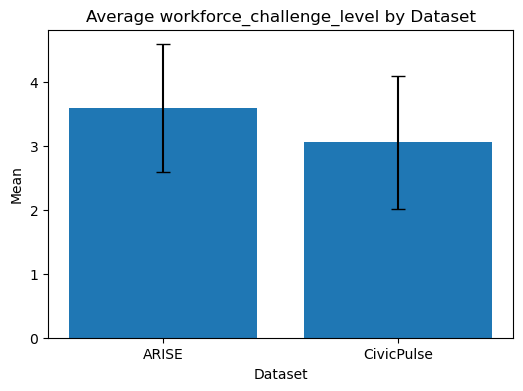

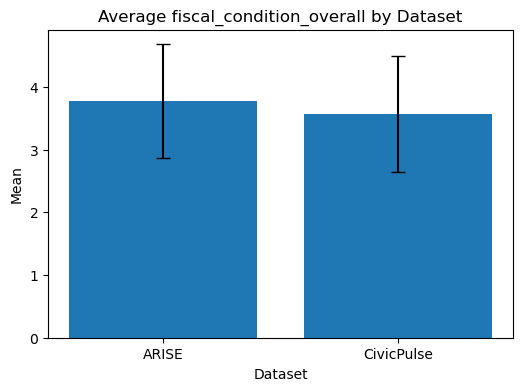

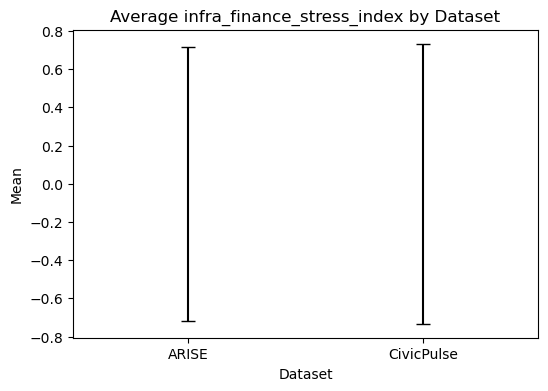

In [213]:
#Bar charts for key variables

for var in direct_compare_vars + ["infra_finance_stress_index"]:
    plot_stats = analysis_df.groupby("source")[var].agg(["mean", "std"])

    plt.figure(figsize=(6, 4))
    plt.bar(plot_stats.index, plot_stats["mean"], yerr=plot_stats["std"], capsize=5)
    plt.title(f"Average {var} by Dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Mean")
    plt.show()


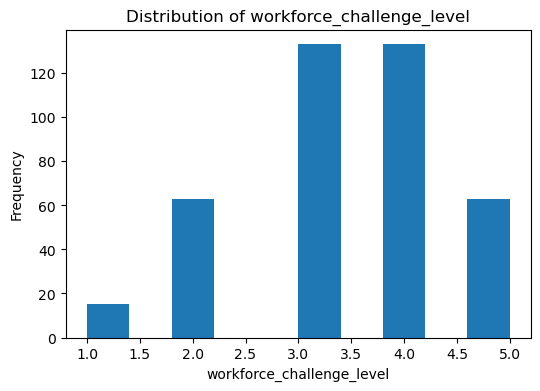

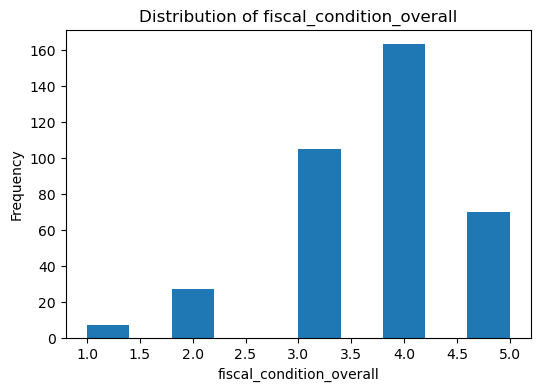

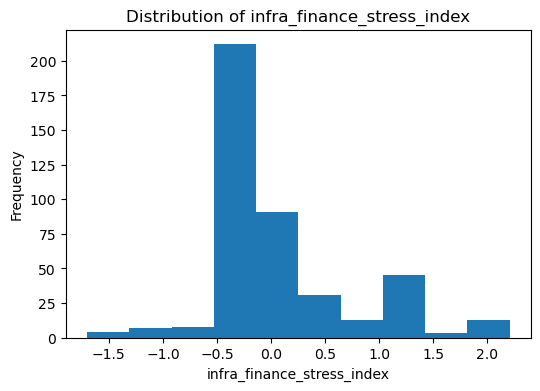

In [214]:
#Histograms

for var in summary_vars:
    plt.figure(figsize=(6, 4))
    analysis_df[var].plot(kind="hist", bins=10)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

<Figure size 600x400 with 0 Axes>

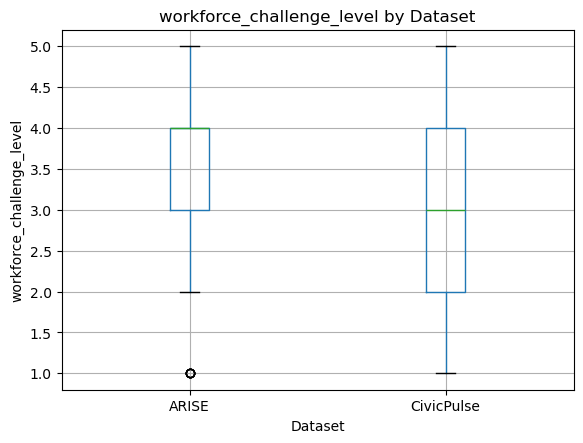

<Figure size 600x400 with 0 Axes>

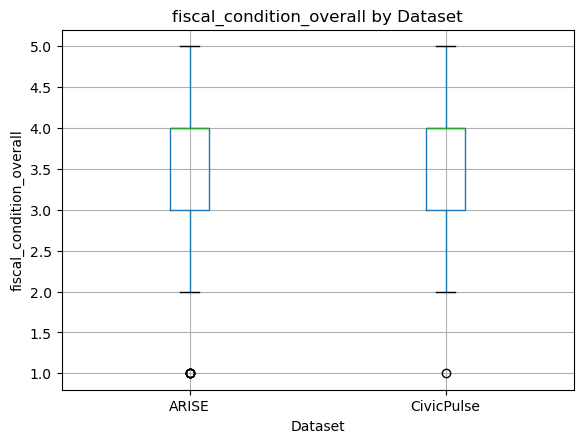

<Figure size 600x400 with 0 Axes>

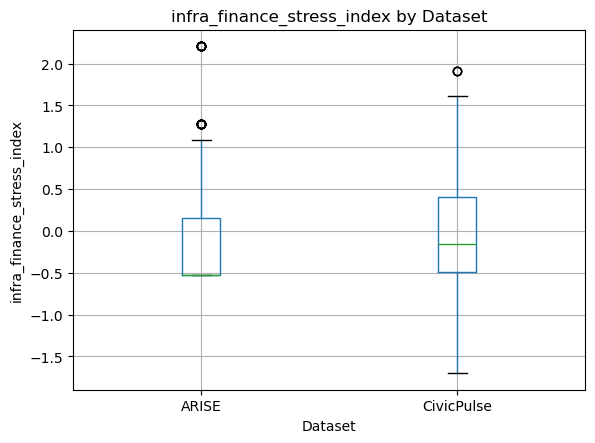

In [215]:
#Boxplots

for var in summary_vars:
    plt.figure(figsize=(6, 4))
    analysis_df.boxplot(column=var, by="source")
    plt.title(f"{var} by Dataset")
    plt.suptitle("")
    plt.xlabel("Dataset")
    plt.ylabel(var)
    plt.show()


In [216]:
#Correlation matrix

correlation_vars = [
    "workforce_challenge_level",
    "fiscal_condition_overall",
    "infra_finance_stress_index"
]

correlation_matrix = analysis_df[correlation_vars].corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,workforce_challenge_level,fiscal_condition_overall,infra_finance_stress_index
workforce_challenge_level,1.000000,-0.194502,0.037675
fiscal_condition_overall,-0.194502,1.000000,-0.007041
infra_finance_stress_index,0.037675,-0.007041,1.000000


In [217]:
#Cross-tabulations

cross_tab_1 = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"],
    dropna=False
)

cross_tab_2 = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["source"],
    dropna=False
)

analysis_df["infra_stress_group"] = pd.qcut(
    analysis_df["infra_finance_stress_index"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

cross_tab_3 = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["infra_stress_group"],
    dropna=False
)

print("Cross-tab: Workforce Challenge vs Fiscal Condition")
display(cross_tab_1)

print("Cross-tab: Workforce Challenge vs Dataset Source")
display(cross_tab_2)

print("Cross-tab: Workforce Challenge vs Infrastructure Stress Group")
display(cross_tab_3)

Cross-tab: Workforce Challenge vs Fiscal Condition


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0,NaN
workforce_challenge_level,,,,,,
1.0,0,1,5,3,5,1
2.0,0,1,11,33,14,4
3.0,0,9,35,47,28,14
4.0,3,11,36,58,15,10
5.0,4,5,18,21,8,7
NaN,0,0,0,1,0,36


Cross-tab: Workforce Challenge vs Dataset Source


source,ARISE,CivicPulse
workforce_challenge_level,,
1.0,6,9
2.0,32,31
3.0,85,48
4.0,97,36
5.0,53,10
NaN,36,1


Cross-tab: Workforce Challenge vs Infrastructure Stress Group


infra_stress_group,Low,Medium,High
workforce_challenge_level,,,
NaN,36,0,1
1.0,6,3,5
2.0,19,24,16
3.0,55,41,29
4.0,49,46,34
5.0,25,18,20


In [218]:
# Cleaned cross-tabs (removing NaN for clarity)

# Workforce vs Fiscal Condition
ct1_clean = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"]
)

ct1_clean = ct1_clean.drop(index=np.nan, errors="ignore")
ct1_clean = ct1_clean.drop(columns=np.nan, errors="ignore")

ct1_clean.index.name = "Workforce Challenge Level"
ct1_clean.columns.name = "Fiscal Condition Level"

print("Clean Cross-tab: Workforce vs Fiscal Condition")
display(ct1_clean)


# Workforce vs Dataset
ct2_clean = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["source"]
)

ct2_clean.index.name = "Workforce Challenge Level"
ct2_clean.columns.name = "Dataset"

print("Clean Cross-tab: Workforce vs Dataset")
display(ct2_clean)


# Workforce vs Infrastructure Stress
ct3_clean = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["infra_stress_group"]
)

ct3_clean.index.name = "Workforce Challenge Level"
ct3_clean.columns.name = "Infrastructure Stress"

print("Clean Cross-tab: Workforce vs Infrastructure Stress")
display(ct3_clean)


Clean Cross-tab: Workforce vs Fiscal Condition


Fiscal Condition Level,1.0,2.0,3.0,4.0,5.0
Workforce Challenge Level,,,,,
1.0,0,1,5,3,5
2.0,0,1,11,33,14
3.0,0,9,35,47,28
4.0,3,11,36,58,15
5.0,4,5,18,21,8


Clean Cross-tab: Workforce vs Dataset


Dataset,ARISE,CivicPulse
Workforce Challenge Level,,
1.0,6,9
2.0,32,31
3.0,85,48
4.0,97,36
5.0,53,10


Clean Cross-tab: Workforce vs Infrastructure Stress


Infrastructure Stress,Low,Medium,High
Workforce Challenge Level,,,
1.0,6,3,5
2.0,19,24,16
3.0,55,41,29
4.0,49,46,34
5.0,25,18,20


In [219]:
# Percentage cross-tabs 

ct1_pct = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"],
    normalize="index"
) * 100

ct1_pct = ct1_pct.round(1)

# add % symbol
ct1_pct = ct1_pct.astype(str) + "%"

print("Percentage Cross-tab: Workforce vs Fiscal Condition")
display(ct1_pct)


ct3_pct = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["infra_stress_group"],
    normalize="index"
) * 100

ct3_pct = ct3_pct.round(1)

# add % symbol
ct3_pct = ct3_pct.astype(str) + "%"

print("Percentage Cross-tab: Workforce vs Infrastructure Stress")
display(ct3_pct)

Percentage Cross-tab: Workforce vs Fiscal Condition


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0
workforce_challenge_level,,,,,
1.0,0.0%,7.1%,35.7%,21.4%,35.7%
2.0,0.0%,1.7%,18.6%,55.9%,23.7%
3.0,0.0%,7.6%,29.4%,39.5%,23.5%
4.0,2.4%,8.9%,29.3%,47.2%,12.2%
5.0,7.1%,8.9%,32.1%,37.5%,14.3%


Percentage Cross-tab: Workforce vs Infrastructure Stress


infra_stress_group,Low,Medium,High
workforce_challenge_level,,,
1.0,42.9%,21.4%,35.7%
2.0,32.2%,40.7%,27.1%
3.0,44.0%,32.8%,23.2%
4.0,38.0%,35.7%,26.4%
5.0,39.7%,28.6%,31.7%


In [220]:
# Optional styling 

ct1_pct.columns = ct1_pct.columns.astype(int)
ct1_pct.index = ct1_pct.index.astype(int)

ct1_pct.style.background_gradient(cmap="Blues")

fiscal_condition_overall,1,2,3,4,5
workforce_challenge_level,,,,,
1,0.0%,7.1%,35.7%,21.4%,35.7%
2,0.0%,1.7%,18.6%,55.9%,23.7%
3,0.0%,7.6%,29.4%,39.5%,23.5%
4,2.4%,8.9%,29.3%,47.2%,12.2%
5,7.1%,8.9%,32.1%,37.5%,14.3%


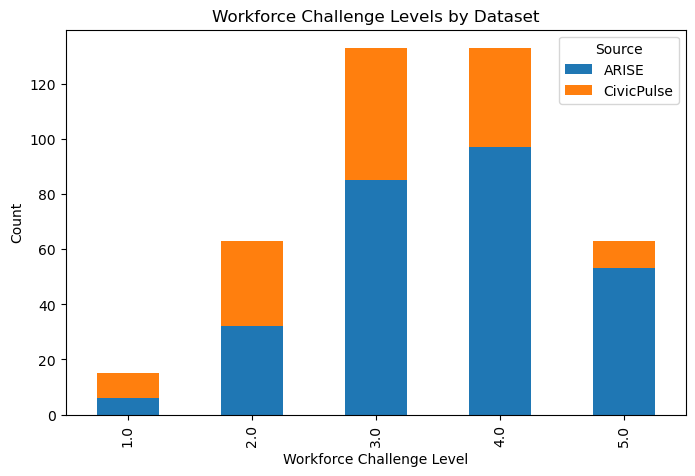

In [221]:
#Stacked bar chart for workforce by source

workforce_source_ct = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["source"]
)

workforce_source_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Workforce Challenge Levels by Dataset")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Count")
plt.legend(title="Source")
plt.show()

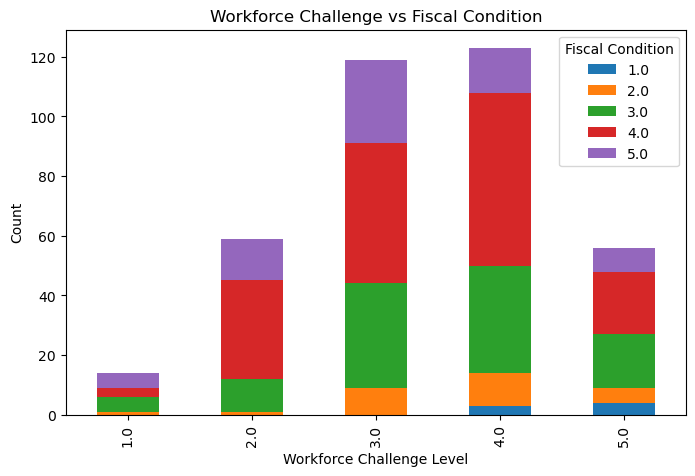

In [222]:
#Stacked bar chart for workforce vs fiscal condition

workforce_fiscal_ct = pd.crosstab(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"]
)

workforce_fiscal_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Workforce Challenge vs Fiscal Condition")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Count")
plt.legend(title="Fiscal Condition")
plt.show()

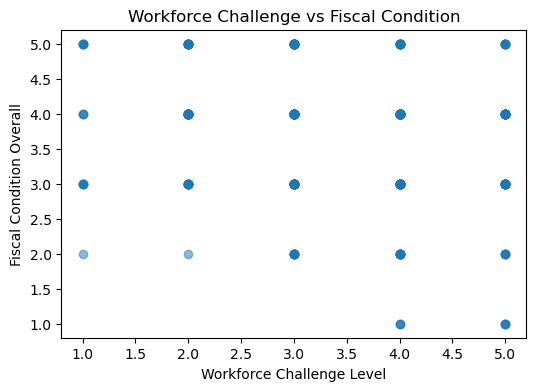

In [223]:
#Scatter plots

plt.figure(figsize=(6, 4))
plt.scatter(
    analysis_df["workforce_challenge_level"],
    analysis_df["fiscal_condition_overall"],
    alpha=0.5
)
plt.title("Workforce Challenge vs Fiscal Condition")
plt.xlabel("Workforce Challenge Level")
plt.ylabel("Fiscal Condition Overall")
plt.show()

In [224]:
# Research questions for the project


research_questions = [
    "RQ1: How are workforce challenges related to overall fiscal condition?",
    "RQ2: How are workforce challenges related to infrastructure finance stress?",
    "RQ3: How do ARISE and CivicPulse compare on the main harmonized measures?",
    "RQ4: What appears to matter more for fiscal condition in the regression analysis?"
]

print("Research Questions")
for rq in research_questions:
    print("-", rq)

Research Questions
- RQ1: How are workforce challenges related to overall fiscal condition?
- RQ2: How are workforce challenges related to infrastructure finance stress?
- RQ3: How do ARISE and CivicPulse compare on the main harmonized measures?
- RQ4: What appears to matter more for fiscal condition in the regression analysis?


In [225]:
#Separate regression by dataset
reg_df = analysis_df[
    [
        "source",
        "fiscal_condition_overall",
        "workforce_challenge_level",
        "infra_finance_stress_index"
    ]
].dropna()

for src in reg_df["source"].unique():
    print(f"\nRegression for {src} dataset\n")

    temp_df = reg_df[reg_df["source"] == src].copy()

    X = temp_df[["workforce_challenge_level", "infra_finance_stress_index"]]
    y = temp_df["fiscal_condition_overall"]

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    print(model.summary())


Regression for ARISE dataset

                               OLS Regression Results                               
Dep. Variable:     fiscal_condition_overall   R-squared:                       0.085
Model:                                  OLS   Adj. R-squared:                  0.077
Method:                       Least Squares   F-statistic:                     11.61
Date:                      Tue, 14 Apr 2026   Prob (F-statistic):           1.50e-05
Time:                              23:14:10   Log-Likelihood:                -324.59
No. Observations:                       254   AIC:                             655.2
Df Residuals:                           251   BIC:                             665.8
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [226]:
#Separate regression by dataset

# Separate datasets
arise_df = analysis_df[analysis_df["source"] == "ARISE"]
civic_df = analysis_df[analysis_df["source"] == "CivicPulse"]

# ARISE regression
X_arise = arise_df[[
    "workforce_challenge_level",
    "infra_finance_stress_index"
]]
X_arise = sm.add_constant(X_arise)

y_arise = arise_df["fiscal_condition_overall"]

model_arise = sm.OLS(y_arise, X_arise, missing="drop").fit()


# CivicPulse regression
X_civic = civic_df[[
    "workforce_challenge_level",
    "infra_finance_stress_index"
]]
X_civic = sm.add_constant(X_civic)

y_civic = civic_df["fiscal_condition_overall"]

model_civic = sm.OLS(y_civic, X_civic, missing="drop").fit()

In [227]:
def extract_regression_results(model, dataset_name):
    return pd.DataFrame({
        "Dataset": dataset_name,
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "P-value": model.pvalues.values
    })

arise_results = extract_regression_results(model_arise, "ARISE")
civic_results = extract_regression_results(model_civic, "CivicPulse")

final_regression_table = pd.concat([arise_results, civic_results], ignore_index=True)

display(final_regression_table.round(3))

,Dataset,Variable,Coefficient,P-value
0,ARISE,const,4.042,0.000
1,ARISE,workforce_challenge_level,-0.067,0.233
2,ARISE,infra_finance_stress_index,-0.325,0.000
3,CivicPulse,const,4.251,0.000
4,CivicPulse,workforce_challenge_level,-0.223,0.002
5,CivicPulse,infra_finance_stress_index,0.610,0.000


In [228]:
#Combined regression
combined_reg_df = analysis_df[
    [
        "source",
        "fiscal_condition_overall",
        "workforce_challenge_level",
        "infra_finance_stress_index"
    ]
].dropna()

source_dummies = pd.get_dummies(combined_reg_df["source"], drop_first=True)

X_combined = pd.concat(
    [
        combined_reg_df[["workforce_challenge_level", "infra_finance_stress_index"]],
        source_dummies
    ],
    axis=1
)

X_combined = X_combined.astype(float)
X_combined = sm.add_constant(X_combined)

y_combined = combined_reg_df["fiscal_condition_overall"].astype(float)

combined_model = sm.OLS(y_combined, X_combined).fit()

print("\nCombined regression with source control\n")
print(combined_model.summary())


   


Combined regression with source control

                               OLS Regression Results                               
Dep. Variable:     fiscal_condition_overall   R-squared:                       0.059
Model:                                  OLS   Adj. R-squared:                  0.052
Method:                       Least Squares   F-statistic:                     7.733
Date:                      Tue, 14 Apr 2026   Prob (F-statistic):           5.07e-05
Time:                              23:14:15   Log-Likelihood:                -483.75
No. Observations:                       371   AIC:                             975.5
Df Residuals:                           367   BIC:                             991.2
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [229]:
# Final regression interpretation

print("\nRegression Analysis Summary\n")

def p_label(p):
    if pd.isna(p):
        return "unknown"
    return "statistically significant" if p < 0.05 else "not statistically significant"

def sign_label(v):
    if pd.isna(v):
        return "unknown"
    return "positive" if v > 0 else "negative"

# build the separate model dictionary only if those models exist
model_dict = {}

if "model_arise" in globals():
    model_dict["ARISE"] = model_arise

if "model_civic" in globals():
    model_dict["CivicPulse"] = model_civic

print("Separate Dataset Models:\n")

if len(model_dict) == 0:
    print("Separate models were not found in the notebook. Skipping separate model interpretation.\n")
else:
    for dataset_name, model in model_dict.items():
        coef_wf = model.params.get("workforce_challenge_level", np.nan)
        p_wf = model.pvalues.get("workforce_challenge_level", np.nan)

        coef_infra = model.params.get("infra_finance_stress_index", np.nan)
        p_infra = model.pvalues.get("infra_finance_stress_index", np.nan)

        print(f"{dataset_name}:")
        print(f"  - Workforce challenge is {p_label(p_wf)} and has a {sign_label(coef_wf)} relationship with fiscal condition.")
        print(f"  - Infrastructure stress is {p_label(p_infra)} and has a {sign_label(coef_infra)} relationship with fiscal condition.\n")

print("Combined Model:\n")

coef_wf_comb = combined_model.params.get("workforce_challenge_level", np.nan)
p_wf_comb = combined_model.pvalues.get("workforce_challenge_level", np.nan)

coef_infra_comb = combined_model.params.get("infra_finance_stress_index", np.nan)
p_infra_comb = combined_model.pvalues.get("infra_finance_stress_index", np.nan)

print(f"  - Workforce challenge is {p_label(p_wf_comb)} and has a {sign_label(coef_wf_comb)} relationship with fiscal condition.")
print(f"  - Infrastructure stress is {p_label(p_infra_comb)} and has a {sign_label(coef_infra_comb)} relationship with fiscal condition.\n")

print("Overall Interpretation:\n")
print("  - These results should be interpreted using the harmonized dataset structure.")
print("  - Differences across ARISE and CivicPulse may reflect variation in survey design, measurement, and sample composition.")
print("  - The combined model is useful for overall direction, while separate models show dataset-specific patterns.\n")



Regression Analysis Summary

Separate Dataset Models:

ARISE:
  - Workforce challenge is not statistically significant and has a negative relationship with fiscal condition.
  - Infrastructure stress is statistically significant and has a negative relationship with fiscal condition.

CivicPulse:
  - Workforce challenge is statistically significant and has a negative relationship with fiscal condition.
  - Infrastructure stress is statistically significant and has a positive relationship with fiscal condition.

Combined Model:

  - Workforce challenge is statistically significant and has a negative relationship with fiscal condition.
  - Infrastructure stress is not statistically significant and has a negative relationship with fiscal condition.

Overall Interpretation:

  - These results should be interpreted using the harmonized dataset structure.
  - Differences across ARISE and CivicPulse may reflect variation in survey design, measurement, and sample composition.
  - The combined 

In [230]:
# Combined regression table 
combined_regression_table = pd.DataFrame({
    "Variable": combined_model.params.index,
    "Coefficient": combined_model.params.values,
    "P-value": combined_model.pvalues.values
})

pretty_names = {
    "const": "Intercept",
    "workforce_challenge_level": "Workforce Challenge Level",
    "infra_finance_stress_index": "Infrastructure Stress Index"
}

combined_regression_table["Variable"] = combined_regression_table["Variable"].replace(pretty_names)

display(combined_regression_table.round(3))


,Variable,Coefficient,P-value
0,Intercept,4.475,0.000
1,Workforce Challenge Level,-0.199,0.000
2,Infrastructure Stress Index,-0.005,0.938
3,CivicPulse,-0.298,0.004


In [163]:
print("\nCombined Regression Summary\n")
print(f"R-squared: {combined_model.rsquared:.3f}")
print(f"Adjusted R-squared: {combined_model.rsquared_adj:.3f}")
print(f"F-statistic p-value: {combined_model.f_pvalue:.3g}")


Combined Regression Summary

R-squared: 0.059
Adjusted R-squared: 0.052
F-statistic p-value: 5.07e-05


In [164]:
#Interpretation table

interpretation_table = pd.DataFrame({
    "Metric": [
        "Workforce Challenge",
        "Fiscal Condition",
        "Infrastructure Stress Index"
    ],
    "ARISE": [
        analysis_df.loc[analysis_df["source"] == "ARISE", "workforce_challenge_level"].mean(),
        analysis_df.loc[analysis_df["source"] == "ARISE", "fiscal_condition_overall"].mean(),
        analysis_df.loc[analysis_df["source"] == "ARISE", "infra_finance_stress_index"].mean()
    ],
    "CivicPulse": [
        analysis_df.loc[analysis_df["source"] == "CivicPulse", "workforce_challenge_level"].mean(),
        analysis_df.loc[analysis_df["source"] == "CivicPulse", "fiscal_condition_overall"].mean(),
        analysis_df.loc[analysis_df["source"] == "CivicPulse", "infra_finance_stress_index"].mean()
    ]
})

display(interpretation_table.round(3))

,Metric,ARISE,CivicPulse
0,Workforce Challenge,3.582,3.052
1,Fiscal Condition,3.768,3.568
2,Infrastructure Stress Index,0.000,-0.000


In [182]:
# Final Insights

wf_arise = analysis_df.loc[analysis_df["source"] == "ARISE", "workforce_challenge_level"].mean()
wf_civic = analysis_df.loc[analysis_df["source"] == "CivicPulse", "workforce_challenge_level"].mean()

fc_arise = analysis_df.loc[analysis_df["source"] == "ARISE", "fiscal_condition_overall"].mean()
fc_civic = analysis_df.loc[analysis_df["source"] == "CivicPulse", "fiscal_condition_overall"].mean()

infra_index_arise = analysis_df.loc[analysis_df["source"] == "ARISE", "infra_finance_stress_index"].mean()
infra_index_civic = analysis_df.loc[analysis_df["source"] == "CivicPulse", "infra_finance_stress_index"].mean()

corr_wf_fc = analysis_df[["workforce_challenge_level", "fiscal_condition_overall"]].corr().iloc[0, 1]
corr_wf_infra = analysis_df[["workforce_challenge_level", "infra_finance_stress_index"]].corr().iloc[0, 1]
corr_fc_infra = analysis_df[["fiscal_condition_overall", "infra_finance_stress_index"]].corr().iloc[0, 1]

def corr_label(x):
    x = abs(x)
    if x < 0.2:
        return "very weak"
    elif x < 0.4:
        return "weak"
    elif x < 0.6:
        return "moderate"
    elif x < 0.8:
        return "strong"
    else:
        return "very strong"


final_insights = pd.DataFrame({
    "Insight No.": [1, 2, 3, 4, 5, 6],
    "Insight": [
        f"ARISE has a higher average workforce challenge ({wf_arise:.3f}) compared to CivicPulse ({wf_civic:.3f}).",

        f"Fiscal condition is slightly higher in ARISE ({fc_arise:.3f}) than in CivicPulse ({fc_civic:.3f}).",

        f"The relationship between workforce challenge and fiscal condition is {corr_label(corr_wf_fc)} (r = {corr_wf_fc:.3f}).",

        f"The relationship between workforce challenge and infrastructure stress is {corr_label(corr_wf_infra)} (r = {corr_wf_infra:.3f}).",

        f"In the separate regressions, infrastructure stress is significant, but its effect is not consistent across ARISE and CivicPulse.",

        f"In the combined model, workforce challenge shows a more stable relationship with fiscal condition, while infrastructure stress is not statistically significant."
    ]
})

print("Final Insights")
pd.set_option('display.max_colwidth', None)
display(final_insights)

Final Insights


,Insight No.,Insight
0,1,ARISE has a higher average workforce challenge (3.582) compared to CivicPulse (3.052).
1,2,Fiscal condition is slightly higher in ARISE (3.768) than in CivicPulse (3.568).
2,3,The relationship between workforce challenge and fiscal condition is very weak (r = -0.195).
3,4,The relationship between workforce challenge and infrastructure stress is very weak (r = 0.038).
4,5,"In the separate regressions, infrastructure stress is significant, but its effect is not consistent across ARISE and CivicPulse."
5,6,"In the combined model, workforce challenge shows a more stable relationship with fiscal condition, while infrastructure stress is not statistically significant."


In [166]:
# Correlation calculations

corr_wf_fc = analysis_df[["workforce_challenge_level", "fiscal_condition_overall"]].corr().iloc[0, 1]
corr_wf_infra = analysis_df[["workforce_challenge_level", "infra_finance_stress_index"]].corr().iloc[0, 1]
corr_fc_infra = analysis_df[["fiscal_condition_overall", "infra_finance_stress_index"]].corr().iloc[0, 1]

In [167]:
# Research question answers


print("\nResearch Question Answers\n")

wf_fc_direction = "negative" if corr_wf_fc < 0 else "positive"
wf_infra_direction = "negative" if corr_wf_infra < 0 else "positive"

print("1. How are workforce challenges related to fiscal condition?")
print(f"Answer: Workforce challenge has a {corr_label(corr_wf_fc)} {wf_fc_direction} relationship with fiscal condition (r = {corr_wf_fc:.3f}).")
print("        This shows whether higher workforce difficulty tends to line up with lower or higher fiscal condition.")
print("        The strength of the pattern should be judged by the size of the correlation.\n")

print("2. How are workforce challenges related to infrastructure pressures?")
print(f"Answer: The relationship between workforce challenge and infrastructure stress is {corr_label(corr_wf_infra)} and {wf_infra_direction} (r = {corr_wf_infra:.3f}).")
print("        This tells us whether staffing problems and infrastructure finance pressure tend to move together.\n")

print("3. How do ARISE and CivicPulse compare on the main harmonized measures?")
print(f"Answer: ARISE has average workforce challenge = {wf_arise:.3f}, while CivicPulse has = {wf_civic:.3f}.")
print(f"        ARISE has average fiscal condition = {fc_arise:.3f}, while CivicPulse has = {fc_civic:.3f}.")
print("        Infrastructure was compared through a standardized stress index because the original item structures differ across surveys.\n")

print("4. What seems to matter more for fiscal condition in the regression?")
print(f"Answer: In the combined model, workforce challenge is {p_label(p_wf_comb)} with a {sign_label(coef_wf_comb)} coefficient.")
print(f"        Infrastructure stress is {p_label(p_infra_comb)} with a {sign_label(coef_infra_comb)} coefficient.")
print("        Separate dataset models should also be reviewed because the direction and significance can vary by survey.\n")


Research Question Answers

1. How are workforce challenges related to fiscal condition?
Answer: Workforce challenge has a very weak negative relationship with fiscal condition (r = -0.195).
        This shows whether higher workforce difficulty tends to line up with lower or higher fiscal condition.
        The strength of the pattern should be judged by the size of the correlation.

2. How are workforce challenges related to infrastructure pressures?
Answer: The relationship between workforce challenge and infrastructure stress is very weak and positive (r = 0.038).
        This tells us whether staffing problems and infrastructure finance pressure tend to move together.

3. How do ARISE and CivicPulse compare on the main harmonized measures?
Answer: ARISE has average workforce challenge = 3.582, while CivicPulse has = 3.052.
        ARISE has average fiscal condition = 3.768, while CivicPulse has = 3.568.
        Infrastructure was compared through a standardized stress index becaus

In [168]:
# Small chart summary table before optional plots

chart_summary = pd.DataFrame({
    "Chart": [
        "Government Type Distribution",
        "Infrastructure / Condition Rating Distribution"
    ],
    "Purpose": [
        "Shows how respondents are distributed across government types",
        "Shows how responses are distributed across condition ratings"
    ],
    "Status": [
        "Will display only if matching column exists",
        "Will display only if matching column exists"
    ]
})

print("Optional Chart Summary")
display(chart_summary)

Optional Chart Summary


,Chart,Purpose,Status
0,Government Type Distribution,Shows how respondents are distributed across g...,Will display only if matching column exists
1,Infrastructure / Condition Rating Distribution,Shows how responses are distributed across con...,Will display only if matching column exists


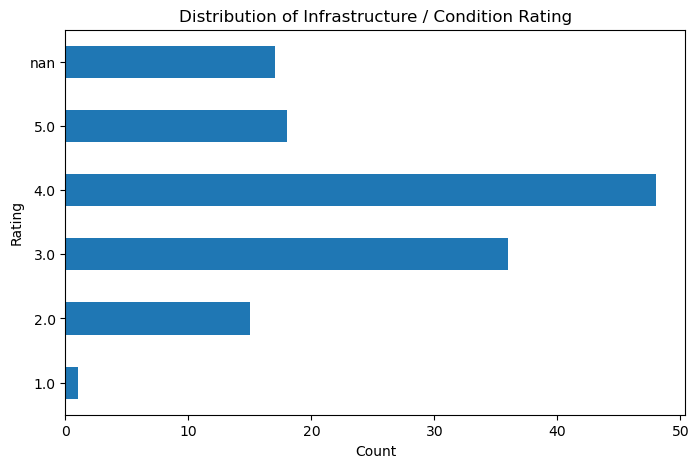

In [169]:
#optional charts


possible_gov_type_cols = [
    "gov_type", "government_type", "jurisdiction_type", "type_of_government"
]

found_gov_type = None
for col in possible_gov_type_cols:
    if col in civic.columns:
        found_gov_type = col
        break

if found_gov_type is not None:
    plt.figure(figsize=(8, 5))
    civic[found_gov_type].value_counts(dropna=False).plot(kind="barh")
    plt.title("Government Type Distribution")
    plt.xlabel("Count")
    plt.ylabel("Government Type")
    plt.show()

possible_infra_rating_cols = [
    "condition_sc", "overall_condition", "capital_assets_condition"
]

found_infra_rating = None
for col in possible_infra_rating_cols:
    if col in civic.columns:
        found_infra_rating = col
        break

if found_infra_rating is not None:
    temp_counts = civic[found_infra_rating].astype(str).value_counts(dropna=False).sort_index()

    plt.figure(figsize=(8, 5))
    temp_counts.plot(kind="barh")
    plt.title("Distribution of Infrastructure / Condition Rating")
    plt.xlabel("Count")
    plt.ylabel("Rating")
    plt.show()

Government Type Distribution


,Government Type,Count,Percentage
0,Municipality,99,73.3%
1,County,24,17.8%
2,Water Special District,9,6.7%
3,Housing Special District,3,2.2%


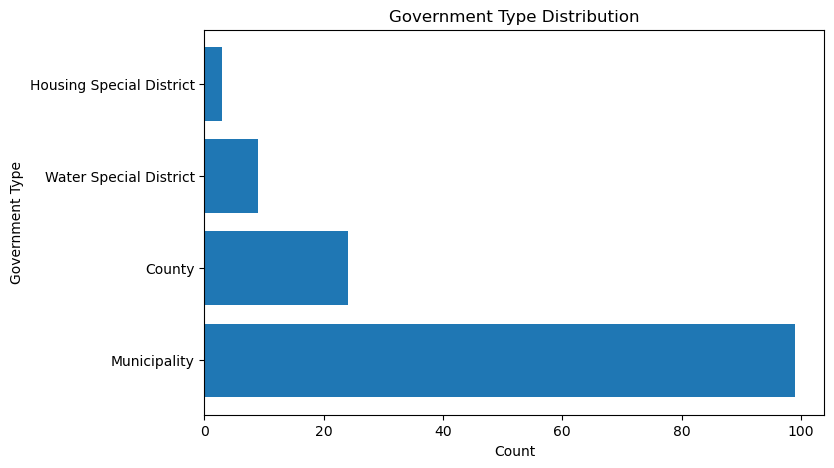

In [170]:
# Optional chart 1: Government type distribution

gov_col = "govtype"

if gov_col in civic.columns:
    gov_counts = civic[gov_col].value_counts(dropna=False).reset_index()
    gov_counts.columns = ["Government Type", "Count"]

    gov_counts["Percentage"] = (
        gov_counts["Count"] / gov_counts["Count"].sum() * 100
    ).round(1).astype(str) + "%"

    print("Government Type Distribution")
    display(gov_counts)

    plt.figure(figsize=(8, 5))
    plt.barh(gov_counts["Government Type"].astype(str), gov_counts["Count"])
    plt.title("Government Type Distribution")
    plt.xlabel("Count")
    plt.ylabel("Government Type")
    plt.show()
else:
    print(f"Column '{gov_col}' not found in CivicPulse dataset.")


In [171]:
# Optional Analysis: Contextual patterns within the CivicPulse sample

print("\nOptional Analysis\n")
print("This section looks at whether key outcomes vary by government type and respondent role within the CivicPulse data.")


Optional Analysis

This section looks at whether key outcomes vary by government type and respondent role within the CivicPulse data.


In [172]:
# Optional Analysis 1: Compare key variables by government type

govtype_summary = civic.groupby("govtype")[
    ["workforce_challenge_level", "fiscal_condition_overall"]
].agg(["mean", "median", "count"])

print("Key measures by government type")
display(govtype_summary.round(3))

Key measures by government type


workforce_challenge_level               \
                                              mean median count   
govtype                                                           
County                                       3.042    3.0    24   
Housing Special District                     2.667    3.0     3   
Municipality                                 3.071    3.0    98   
Water Special District                       3.000    3.0     9   

                         fiscal_condition_overall               
                                             mean median count  
govtype                                                         
County                                      3.810    4.0    21  
Housing Special District                    3.000    3.0     2  
Municipality                                3.552    4.0    87  
Water Special District                      3.250    3.5     8

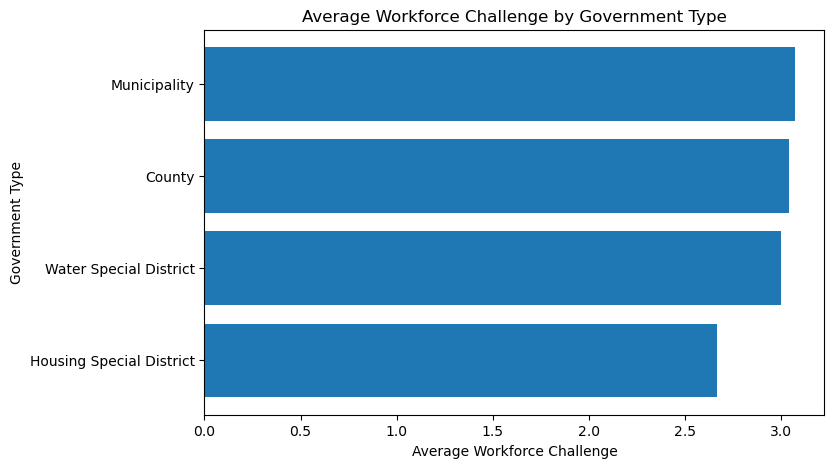

In [173]:
# Average workforce challenge by government type

govtype_workforce = civic.groupby("govtype")["workforce_challenge_level"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(govtype_workforce.index.astype(str), govtype_workforce.values)
plt.title("Average Workforce Challenge by Government Type")
plt.xlabel("Average Workforce Challenge")
plt.ylabel("Government Type")
plt.show()

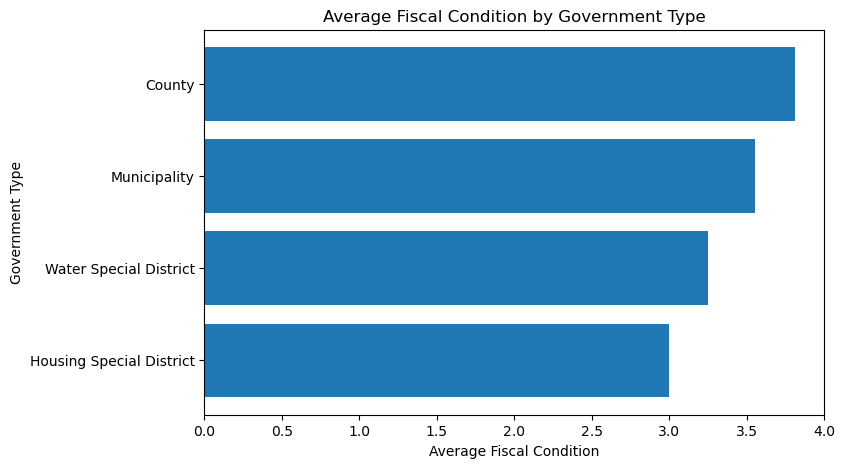

In [174]:
# Average fiscal condition by government type

govtype_fiscal = civic.groupby("govtype")["fiscal_condition_overall"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(govtype_fiscal.index.astype(str), govtype_fiscal.values)
plt.title("Average Fiscal Condition by Government Type")
plt.xlabel("Average Fiscal Condition")
plt.ylabel("Government Type")
plt.show()

In [175]:
# Optional Analysis 2: Compare key variables by respondent role

role_summary = civic.groupby("roletype")[
    ["workforce_challenge_level", "fiscal_condition_overall"]
].agg(["mean", "median", "count"])

print("Key measures by respondent role")
display(role_summary.round(3))

Key measures by respondent role


workforce_challenge_level               \
                                                  mean median count   
roletype                                                              
Civil Service Leader                             3.155    3.0    58   
County/Municipal Policymaker                     2.974    3.0    76   

                             fiscal_condition_overall               
                                                 mean median count  
roletype                                                            
Civil Service Leader                            3.240    3.0    50  
County/Municipal Policymaker                    3.809    4.0    68

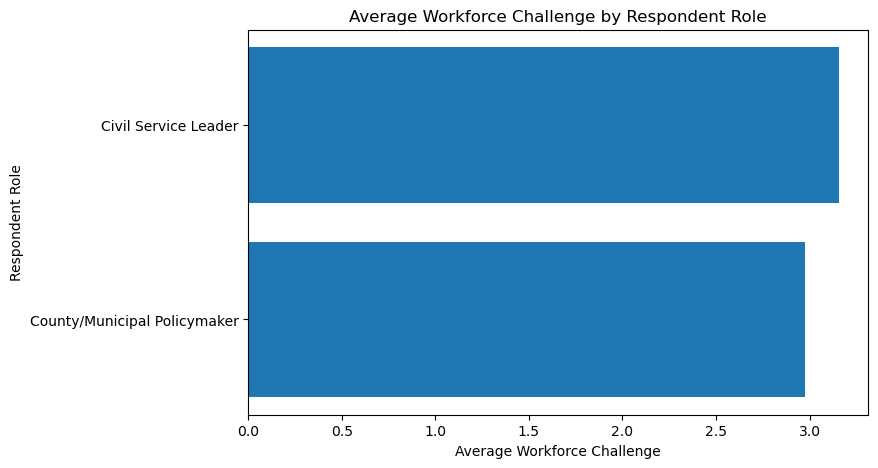

In [176]:
# Average workforce challenge by respondent role

role_workforce = civic.groupby("roletype")["workforce_challenge_level"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(role_workforce.index.astype(str), role_workforce.values)
plt.title("Average Workforce Challenge by Respondent Role")
plt.xlabel("Average Workforce Challenge")
plt.ylabel("Respondent Role")
plt.show()

Top 10 governments or places by number of responses


,Government / Place,Count
0,City Of Paola,4
1,City Of Osage,3
2,City Of Lyons,3
3,City Of Iola,3
4,City Of Edgerton,2
5,Unified Government Of Wyandotte County And Kan...,2
6,City Of Wakefield,2
7,City Of Lyndon,2
8,City Of Valley Center,2
9,City Of Sabetha,2


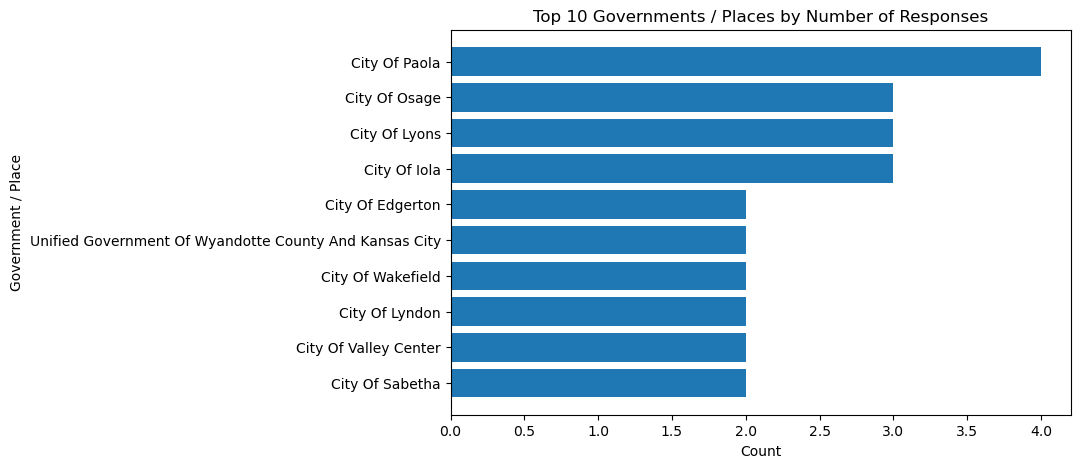

In [177]:
# Optional Analysis 3: Which places appear most often in the CivicPulse responses

place_counts = civic["govname"].value_counts().head(10).reset_index()
place_counts.columns = ["Government / Place", "Count"]

print("Top 10 governments or places by number of responses")
display(place_counts)

plt.figure(figsize=(8, 5))
plt.barh(place_counts["Government / Place"][::-1], place_counts["Count"][::-1])
plt.title("Top 10 Governments / Places by Number of Responses")
plt.xlabel("Count")
plt.ylabel("Government / Place")
plt.show()


In [178]:
# Optional Analysis Interpretation

print("\nOptional Analysis Interpretation\n")

highest_govtype_workforce = govtype_workforce.idxmax()
lowest_govtype_workforce = govtype_workforce.idxmin()

highest_govtype_fiscal = govtype_fiscal.idxmax()
lowest_govtype_fiscal = govtype_fiscal.idxmin()

print(f"1. Among government types, {highest_govtype_workforce} shows the highest average workforce challenge, while {lowest_govtype_workforce} shows the lowest.")
print(f"2. For fiscal condition, {highest_govtype_fiscal} has the highest average score, while {lowest_govtype_fiscal} has the lowest.")
print("3. These subgroup differences suggest that local context may shape how workforce and fiscal conditions are reported.")
print("4. This optional analysis adds context to the main harmonized results by showing that conditions are not uniform across all local governments.")


Optional Analysis Interpretation

1. Among government types, Municipality shows the highest average workforce challenge, while Housing Special District shows the lowest.
2. For fiscal condition, County has the highest average score, while Housing Special District has the lowest.
3. These subgroup differences suggest that local context may shape how workforce and fiscal conditions are reported.
4. This optional analysis adds context to the main harmonized results by showing that conditions are not uniform across all local governments.


In [179]:
# Optional Analysis 4: Government type vs fiscal condition distribution

govtype_fiscal_ct = pd.crosstab(civic["govtype"], civic["fiscal_condition_overall"])

print("Government type vs fiscal condition")
display(govtype_fiscal_ct)

govtype_fiscal_pct = pd.crosstab(
    civic["govtype"],
    civic["fiscal_condition_overall"],
    normalize="index"
) * 100

govtype_fiscal_pct = govtype_fiscal_pct.round(1).astype(str) + "%"

print("Government type vs fiscal condition (row percentages)")
display(govtype_fiscal_pct)

Government type vs fiscal condition


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0
govtype,,,,,
County,0,0,7,11,3
Housing Special District,0,1,0,1,0
Municipality,0,13,27,33,14
Water Special District,1,1,2,3,1


Government type vs fiscal condition (row percentages)


fiscal_condition_overall,1.0,2.0,3.0,4.0,5.0
govtype,,,,,
County,0.0%,0.0%,33.3%,52.4%,14.3%
Housing Special District,0.0%,50.0%,0.0%,50.0%,0.0%
Municipality,0.0%,14.9%,31.0%,37.9%,16.1%
Water Special District,12.5%,12.5%,25.0%,37.5%,12.5%


In [180]:
# Project goal completion check
project_goal_check = pd.DataFrame({
    "Project Requirement": [
        "Reviewed overlapping constructs",
        "Created harmonized variables",
        "Documented harmonization decisions",
        "Combined the datasets",
        "Conducted descriptive analysis",
        "Performed regression-based exploration",
        "Produced visualizations",
        "Prepared final analytical dataset"
    ],
    "Status": [
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done"
    ]
})


In [181]:
# Final Conclusion (revised)

print("\nFinal Conclusion\n")

print("This analysis used harmonized survey data from ARISE and CivicPulse to examine workforce challenges, fiscal condition, and infrastructure stress.")

print("\nOverall, workforce challenge has a weak negative relationship with fiscal condition, while its relationship with infrastructure stress is minimal in the combined data.")

print("\nThe separate regression models show that infrastructure stress is important within each dataset,")
print("but its effect is not fully consistent across ARISE and CivicPulse.")

print("\nIn the combined regression, workforce challenge shows the more stable negative relationship with fiscal condition,")
print("while infrastructure stress is not statistically significant after accounting for dataset source.")

print("\nThese findings show why harmonization matters when combining surveys with different structures and scales.")
print("They also suggest that the relationship between local government capacity measures can look different depending on whether datasets are analyzed separately or together.")


Final Conclusion

This analysis used harmonized survey data from ARISE and CivicPulse to examine workforce challenges, fiscal condition, and infrastructure stress.

Overall, workforce challenge has a weak negative relationship with fiscal condition, while its relationship with infrastructure stress is minimal in the combined data.

The separate regression models show that infrastructure stress is important within each dataset,
but its effect is not fully consistent across ARISE and CivicPulse.

In the combined regression, workforce challenge shows the more stable negative relationship with fiscal condition,
while infrastructure stress is not statistically significant after accounting for dataset source.

These findings show why harmonization matters when combining surveys with different structures and scales.
They also suggest that the relationship between local government capacity measures can look different depending on whether datasets are analyzed separately or together.


In [73]:
analysis_df.to_csv("harmonized_analysis_dataset.csv", index=False)
harmonization_notes.to_csv("harmonization_notes.csv", index=False)
crosswalk_table.to_csv("crosswalk_table.csv", index=False)
project_goal_check.to_csv("project_goal_check.csv", index=False)

interpretation_table.to_csv("interpretation_table.csv", index=False)
final_regression_table.to_csv("regression_results.csv", index=False)
final_insights.to_csv("final_insights.csv", index=False)

print("All files saved successfully.")

All files saved successfully.
